# 📊 EXPLORATORY DATA ANALYSIS — AI Tech vs Traditional (Stage 2)

**Dataset:** S&P 500 Tech (2010-nay) + Tech Top 50 + Financials + Market Cap Scatter  
**Ngon ngu:** Python | **Moi truong:** Jupyter Notebook

---

## 1. 🎯 MUC TIEU GIAI DOAN 2

- Thong ke mo ta daily return theo nhom AI vs Traditional
- Phan tich volatility (rolling 30/90 ngay)
- Danh gia market cap theo nhom va xu huong
- Chuan bi du lieu cho giai doan dinh luong

---

## 2. 📂 DU LIEU DAU VAO

| File | Mo ta |
|------|-------|
| `SnP_daily_update.csv` | Gia Close/Open/High/Low/Volume hang ngay |
| `Top 50 US Tech Companies 2022 - 2023.csv` | Thong tin 50 cong ty tech |
| `constituents-financials.csv` | Chi so tai chinh (P/E, Dividend Yield, EBITDA, Market Cap) |
| `scatter-data.csv` | Market cap va P/E ratio |

---

## 3. 🗺️ QUY TRINH PHAN TICH (STAGE 2)

```
1) Gan nhan AI vs Traditional theo danh sach ticker
2) Thong ke mo ta return (mean/median/std/skew/kurtosis)
3) Volatility rolling 30/90 ngay theo nhom
4) Market cap so sanh theo nhom
```

---

## 4. 🛠️ THU VIEN SU DUNG

| Nhom | Thu vien | Muc dich |
|------|----------|----------|
| Xu ly du lieu | `pandas`, `numpy` | Lam sach, thong ke, reshape |
| Truc quan | `matplotlib`, `seaborn` | Bar/Line/Box plots |

---

## 5. 📦 OUTPUT GIAI DOAN 2

- `returns_long`: daily return theo ticker va nhom
- `stats_by_group`: thong ke mo ta theo nhom
- `vol_rolling`: rolling volatility 30/90 ngay
- Bieu do: mean return, volatility, market cap so sanh

---

## 6. ⚙️ SETUP & EDA

In [15]:
# Import thu vien
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
print('✅ Import thanh cong!')

✅ Import thanh cong!


In [16]:
# 1) Load cleaned data from Data_collection
snp_long = pd.read_csv('dataset/processed/snp_long.csv', parse_dates=['Date'])
tech_df = pd.read_csv('dataset/processed/tech_df.csv')
fin_merged = pd.read_csv('dataset/processed/fin_merged.csv')

print('✅ Loaded snp_long:', snp_long.shape)
print('✅ Loaded tech_df:', tech_df.shape)
print('✅ Loaded fin_merged:', fin_merged.shape)

✅ Loaded snp_long: (424051, 8)
✅ Loaded tech_df: (50, 11)
✅ Loaded fin_merged: (503, 19)


In [17]:
# 2) Ensure ai_group exists (fallback if missing)
ai_focused = {
    'NVDA', 'MSFT', 'GOOG', 'META', 'AMD', 'AMZN', 'CRM', 'PLTR', 'SNPS', 'CDNS',
    'NOW', 'CRWD', 'PANW', 'ADBE', 'INTC', 'ORCL', 'ANET'
}
traditional = {
    'AAPL', 'CSCO', 'HPE', 'HPQ', 'IBM', 'DELL', 'BBY', 'GLW', 'STX', 'WDC', 'SWKS',
    'TER', 'KEYS', 'MCHP', 'QCOM', 'TXN', 'KLAC', 'LRCX', 'AMAT', 'FFIV', 'AKAM',
    'GEN', 'VRSN', 'FISV', 'ADP', 'BR', 'NDAQ', 'ICE', 'CME', 'CBOE'
}

def ai_group_from_ticker(ticker):
    if ticker in ai_focused:
        return 'AI-focused'
    if ticker in traditional:
        return 'Traditional'
    return 'Unclassified'

if 'ai_group' not in tech_df.columns:
    tech_df['ai_group'] = tech_df['Stock Name'].apply(ai_group_from_ticker)

print('✅ Tech companies ready:', tech_df.shape)

✅ Tech companies ready: (50, 11)


In [18]:
# 3) Tao returns_long va thong ke mo ta theo nhom
returns_long = snp_long[['Date', 'ticker', 'daily_return']].copy()
returns_long = returns_long.merge(
    tech_df[['Stock Name', 'ai_group']],
    left_on='ticker', right_on='Stock Name', how='left'
).drop(columns=['Stock Name'])

stats_by_group = returns_long.groupby('ai_group')['daily_return'].agg(
    mean_return='mean',
    median_return='median',
    std_return='std',
    skew_return='skew',
    kurt_return='kurt'
).reset_index()

stats_by_group

,ai_group,mean_return,median_return,std_return,skew_return,kurt_return
0,AI-focused,0.001098,0.001023,0.023539,0.424245,16.621315
1,Traditional,0.000857,0.000905,0.020368,-0.116010,15.427122
2,Unclassified,0.001045,0.000951,0.024634,0.254160,13.400205


C:\Users\PC\AppData\Local\Temp\ipykernel_10652\2295357807.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats_by_group, x='ai_group', y='mean_return', ax=axes[0], palette='Blues')
C:\Users\PC\AppData\Local\Temp\ipykernel_10652\2295357807.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats_by_group, x='ai_group', y='std_return', ax=axes[1], palette='Oranges')


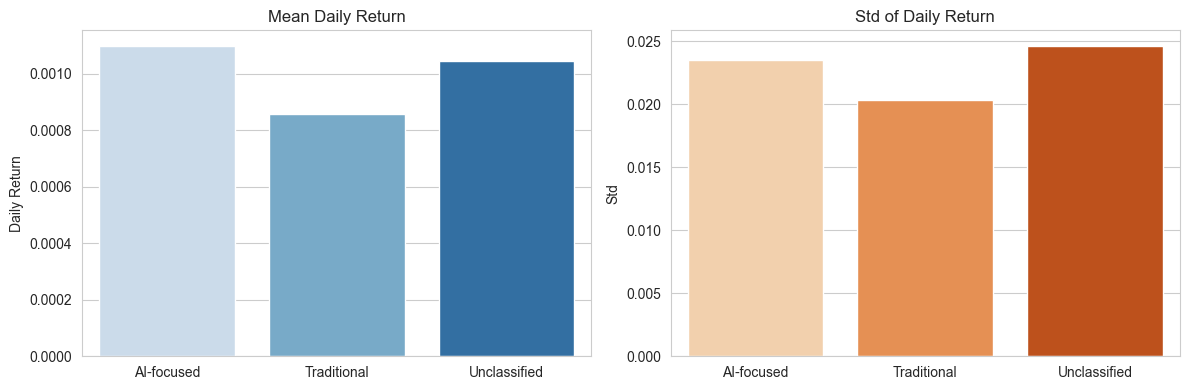

In [19]:
# 4) Bieu do mean return va std return
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=stats_by_group, x='ai_group', y='mean_return', ax=axes[0], palette='Blues')
axes[0].set_title('Mean Daily Return')
axes[0].set_xlabel('')
axes[0].set_ylabel('Daily Return')

sns.barplot(data=stats_by_group, x='ai_group', y='std_return', ax=axes[1], palette='Oranges')
axes[1].set_title('Std of Daily Return')
axes[1].set_xlabel('')
axes[1].set_ylabel('Std')
plt.tight_layout()